# Lecture: Modern Large Language Models (LLMs) Under the Hood
In this lecture, we will look under the hood of modern Large Language Models (LLMs) using the cutting-edge **Qwen3** family. We will explore tokenization, visualize the Attention mechanism, compare standard Instruct Mode (System 1) with Thinking Mode (System 2), fine-tune the model using LoRA, and learn how to manage GPU memory.

We are using **Qwen3-1.7B** (1.7 Billion parameters).

In [ ]:
# Cell 1: check existing Colab torch/CUDA
import torch, sys

print("python:", sys.version)
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.11.0+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4


In [ ]:
# Cell 2: install only non-torch utilities + torchao
!pip install -q -U transformers peft seaborn matplotlib tiktoken humanize GPUtil
!pip install -q outlines "pydantic==2.12.3"
!pip install -q "torchao>=0.16.0" --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.7 MB/s eta 0:00:00


In [ ]:
# Check if T4 GPU is allocated properly
!nvidia-smi

Tue Jun  2 13:30:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Cell 3: verify
import torch
import torchao
import transformers
import pydantic

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("torchao:", torchao.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.11.0+cu128
torch cuda: 12.8
torchao: 0.17.0
cuda available: True


## 1. Environment Setup & Memory Monitoring
First, we install the necessary libraries. We also define a custom function to monitor our RAM and GPU VRAM dynamically.


In [ ]:
# Import packages for memory monitoring
import os, sys, humanize, psutil, GPUtil

# Define memory reporting function
def mem_report():
    """Prints the available System RAM and GPU VRAM in a human-readable format."""
    print("CPU RAM Free: " + humanize.naturalsize(psutil.virtual_memory().available))

    GPUs = GPUtil.getGPUs()
    for i, gpu in enumerate(GPUs):
        print('GPU {:d} ... VRAM Free: {:.0f}MB / {:.0f}MB | Utilization {:3.0f}%'.format(
            i, gpu.memoryFree, gpu.memoryTotal, gpu.memoryUtil * 100))

print("--- Initial Memory Status ---")
mem_report()

--- Initial Memory Status ---
CPU RAM Free: 11.2 GB
GPU 0 ... VRAM Free: 14910MB / 15360MB | Utilization   0%


## 2. Model Loading & VRAM Math
> ### VRAM Math: Will our model fit?
> * **Parameters:** Qwen3-1.7B has 1.7 Billion parameters.
> * **Weight Size:** Loaded in `FP16` (16-bit Float), each parameter takes **2 bytes**. $1.7 \text{ B} \times 2 \text{ bytes} = \mathbf{3.4 \text{ GB}}$ to store the model weights.
> * **Training Overhead:** During fine-tuning (even with LoRA), PyTorch needs extra memory for gradients, optimizer states (AdamW), and activations. Usually, you need roughly 1.5x to 2x the model's weight.
> * **Conclusion:** Our 1.7B model will take about 6-7 GB of VRAM during LoRA training, perfectly fitting into our 16 GB T4. A 7B or 8B model would take up to 16 GB just for weights, causing an "Out of Memory" crash!

Let's load the model and check how the VRAM drops. We intentionally force `attn_implementation="eager"` to disable memory optimizations (like FlashAttention) so the model outputs raw attention matrices for us to visualize later.

In [ ]:
import torch
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

# Define device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Using Qwen3 1.7 Billion parameters
model_id = "Qwen/Qwen3-1.7B"

# Load tokenizer with trust_remote_code
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load model with eager attention and trust_remote_code
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    attn_implementation="eager",
    trust_remote_code=True # Bypass older transformers versions by trusting the model's own code
).to(device)

print("\nQwen3-1.7B successfully loaded on GPU!")
print("--- Memory Status After Loading Model ---")
mem_report()

Using device: cuda


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Qwen3-1.7B successfully loaded on GPU!
--- Memory Status After Loading Model ---
CPU RAM Free: 6.4 GB
GPU 0 ... VRAM Free: 11516MB / 15360MB | Utilization  22%


## 3. Tokenization: What do LLMs actually see?
Neural networks do not process text; they process numbers. This translation is called **tokenization**. Modern LLMs have massive vocabularies (~150,000+ tokens), making them extremely efficient across different languages and code.

In [ ]:
# A curated list of examples to demonstrate modern tokenization
texts = [
    # 1. Basic English & Numbers (Notice how $ and numbers split)
    "Hello, tokenizer! Price: $19.99",

    # 2. Russian Language (Massive improvement over GPT-2, highly efficient)
    "Привет, мир! Ёжик съел 3 яблока.",

    # 3. Python Code (Notice how 4 spaces become a single token)
    "def fine_tune(model):\n    return True",

    # 4. Multilingual & Emoji (Proves the vocabulary is huge and multimodal)
    "Qwen3: Hello / Привет / 你好 🚀✨"
]

print("How a modern LLM sees text:\n" + "="*50)

for t in texts:
    token_ids = tokenizer.encode(t)
    # Decode each ID individually to show the exact text chunks
    readable_tokens = [tokenizer.decode([tid]) for tid in token_ids]

    print(f"Text: {t}")
    print(f"Chunks ({len(readable_tokens)} pcs): {readable_tokens}")
    print(f"IDs: {token_ids}\n" + "-"*50)

How a modern LLM sees text:
Text: Hello, tokenizer! Price: $19.99
Chunks (12 pcs): ['Hello', ',', ' tokenizer', '!', ' Price', ':', ' $', '1', '9', '.', '9', '9']
IDs: [9707, 11, 45958, 0, 8483, 25, 400, 16, 24, 13, 24, 24]
--------------------------------------------------
Text: Привет, мир! Ёжик съел 3 яблока.
Chunks (19 pcs): ['Пр', 'ив', 'ет', ',', ' мир', '!', ' �', '�', 'ж', 'ик', ' с', 'ъ', 'ел', ' ', '3', ' я', 'бл', 'ока', '.']
IDs: [53645, 26991, 8178, 11, 137144, 0, 1278, 223, 16964, 37722, 5409, 33594, 12121, 220, 18, 45310, 125780, 73251, 13]
--------------------------------------------------
Text: def fine_tune(model):
    return True
Chunks (9 pcs): ['def', ' fine', '_t', 'une', '(model', '):\n', '   ', ' return', ' True']
IDs: [750, 6915, 528, 2886, 7635, 982, 262, 470, 3007]
--------------------------------------------------
Text: Qwen3: Hello / Привет / 你好 🚀✨
Chunks (16 pcs): ['Q', 'wen', '3', ':', ' Hello', ' /', ' Пр', 'ив', 'ет', ' /', ' ', '你好', ' �', '�', '�', '✨

## 4. The Evolution: System 1 (Instruct) vs System 2 (Thinking)
Historically, LLMs answered immediately, predicting the next word based on patterns (**System 1**). Modern models (like the Qwen3 family) have built-in **System 2** (Thinking Mode).

Instead of writing complex prompts to force the model to think, modern tokenizers have native flags to toggle this behavior! Let's test this with a classic logic trap: *"Anna's mother has three daughters. The first is named April, the second is named May. What is the name of the third daughter?"* (The correct answer is Anna).

We will use the official Qwen3 API feature: `enable_thinking`.

In [ ]:
logic_question = "Anna's mother has three daughters. The first is named Spring, the second is named Summer. What is the name of the third daughter?"

In [ ]:
print("==========================================")
print(" TEST 1: FORCED INSTINCT (1-Word Answer)")
print("==========================================\n")
messages_1 = [
    {"role": "system", "content": "You are a fast assistant. Answer immediately in exactly one word. No explanations."},
    {"role": "user", "content": logic_question}
]
text_1 = tokenizer.apply_chat_template(messages_1,
                                       tokenize=False,
                                       add_generation_prompt=True,
                                       enable_thinking=False)
inputs_1 = tokenizer([text_1], return_tensors="pt").to(device)

with torch.no_grad():
    out_ids_1 = model.generate(**inputs_1,
                               max_new_tokens=10,
                               do_sample=False,
                               eos_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(out_ids_1[0][inputs_1.input_ids.shape[1]:], skip_special_tokens=True).strip())

 TEST 1: FORCED INSTINCT (1-Word Answer)

Spring


In [ ]:
print("\n\n==========================================")
print(" TEST 2: REASONING ALOUD (Classic CoT)")
print("==========================================\n")
messages_2 = [
    {"role": "user", "content": logic_question + " Please think step-by-step and then give your answer."}
]
text_2 = tokenizer.apply_chat_template(messages_2,
                                       tokenize=False,
                                       add_generation_prompt=True,
                                       enable_thinking=False)
inputs_2 = tokenizer([text_2], return_tensors="pt").to(device)

with torch.no_grad():
    out_ids_2 = model.generate(**inputs_2,
                               max_new_tokens=1024,
                               do_sample=False,
                               eos_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(out_ids_2[0][inputs_2.input_ids.shape[1]:], skip_special_tokens=True).strip())



 TEST 2: REASONING ALOUD (Classic CoT)

Let's break this down step by step.

### Step 1: Understand the names given
- The first daughter is named **Spring**.
- The second daughter is named **Summer**.

### Step 2: Consider the word "Spring" and "Summer"
- These are **seasons**.
- The word **"Spring"** is the **first season** of the year.
- The word **"Summer"** is the **second season** of the year.

### Step 3: Think about the phrase "three daughters"
- The question says: "Anna's mother has three daughters."
- The first two are named **Spring** and **Summer**.
- The third daughter is **not named** in the question.

### Step 4: Use the wordplay
- The word **"Spring"** and **"Summer"** are **seasons**, and the **third daughter** is the **third season** of the year.
- The third season is **Autumn**.

### Final Answer:
The name of the third daughter is **Autumn**.


In [ ]:
print("\n\n==========================================")
print(" TEST 3: NATIVE THINKING (Hidden System 2)")
print("==========================================\n")
messages_3 = [
    {"role": "user", "content": logic_question}
]
# enable_thinking=True turns on the official Qwen3 internal monologue feature
text_3 = tokenizer.apply_chat_template(messages_3,
                                       tokenize=False,
                                       add_generation_prompt=True,
                                       enable_thinking=True)
inputs_3 = tokenizer([text_3], return_tensors="pt").to(device)

with torch.no_grad():
    out_ids_3 = model.generate(**inputs_3,
                               max_new_tokens=32768,
                               do_sample=False,
                               eos_token_id=tokenizer.eos_token_id)

output_ids_3 = out_ids_3[0][inputs_3.input_ids.shape[1]:].tolist()
try:
    index = len(output_ids_3) - output_ids_3[::-1].index(151668) # 151668 is </think>
except ValueError:
    index = 0

print("HIDDEN THOUGHT PROCESS:")
print(tokenizer.decode(output_ids_3[:index], skip_special_tokens=True).strip())
print("\nFINAL VISIBLE ANSWER:")
print(tokenizer.decode(output_ids_3[index:], skip_special_tokens=True).strip())



 TEST 3: NATIVE THINKING (Hidden System 2)

HIDDEN THOUGHT PROCESS:
<think>
Okay, let's try to figure out this riddle. So, the question is: Anna's mother has three daughters. The first is named Spring, the second is named Summer. What is the name of the third daughter?

Hmm, let's start by breaking down the information. The mother has three daughters. The first daughter is named Spring, the second is Summer. The question is asking for the name of the third daughter. 

Wait, the problem says "Anna's mother has three daughters." So, Anna is one of the daughters? Or is Anna the mother? Wait, the wording is a bit confusing. Let me read it again: "Anna's mother has three daughters. The first is named Spring, the second is named Summer. What is the name of the third daughter?"

So, Anna is the mother, right? Because it says "Anna's mother has three daughters." So Anna is the mother, and she has three daughters. The first daughter is Spring, the second is Summer. The third daughter's name i

In [ ]:
print("\n\n==========================================")
print(" TEST 4: STRUCTURED OUTPUT (JSON)")
print("==========================================\n")
messages_4 = [
    {"role": "system", "content": "You are an API endpoint. You MUST respond ONLY in valid JSON format containing two keys: 'reasoning' (your step-by-step logic) and 'answer' (the final name). Do not add any markdown blocks or extra text."},
    {"role": "user", "content": logic_question}
]
text_4 = tokenizer.apply_chat_template(messages_4,
                                       tokenize=False,
                                       add_generation_prompt=True,
                                       enable_thinking=False)
inputs_4 = tokenizer([text_4], return_tensors="pt").to(device)

with torch.no_grad():
    out_ids_4 = model.generate(**inputs_4,
                               max_new_tokens=32768,
                               do_sample=False,
                               eos_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(out_ids_4[0][inputs_4.input_ids.shape[1]:], skip_special_tokens=True).strip())



 TEST 4: STRUCTURED OUTPUT (JSON)

{
  "reasoning": "The problem states that Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself, as the question asks for the name of the third daughter.",
  "answer": "Anna"
}


# Using real structured output

In [ ]:
from pydantic import BaseModel
import outlines


class LogicAnswer(BaseModel):
    reasoning: str
    answer: str


print("\n\n==========================================")
print(" TEST 4: STRUCTURED OUTPUT (JSON) WITH OUTLINES")
print("==========================================\n")

outlines_model = outlines.from_transformers(model, tokenizer)

prompt_4 = tokenizer.apply_chat_template(
    [
        {
            "role": "system",
            "content": (
                "You are an API endpoint. "
                "You MUST respond ONLY in valid JSON format containing two keys: "
                "'reasoning' and 'answer'. "
                "Do not add any markdown blocks or extra text."
            ),
        },
        {
            "role": "user",
            "content": logic_question,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
)

raw_result_4 = outlines_model(
    prompt_4,
    LogicAnswer,
    max_new_tokens=512,
)

print("RAW:")
print(raw_result_4)

result_4 = LogicAnswer.model_validate_json(raw_result_4)

print("\nPARSED:")
print(result_4.model_dump())
print("answer:", result_4.answer)
print("reasoning:", result_4.reasoning)



 TEST 4: STRUCTURED OUTPUT (JSON) WITH OUTLINES

RAW:
{"reasoning": "The question states that Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself, as she is the mother of the three daughters.", "answer": "Anna"}

PARSED:
{'reasoning': "The question states that Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself, as she is the mother of the three daughters.", 'answer': 'Anna'}
answer: Anna
reasoning: The question states that Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself, as she is the mother of the three daughters.


# Another way of structured output

In [ ]:
from pydantic import BaseModel
import json
import torch


class LogicAnswer(BaseModel):
    reasoning: str
    answer: str

In [ ]:
def generate_json_with_pydantic_validation(
    messages,
    response_format,
    model,
    tokenizer,
    device,
    max_new_tokens=512,
):
    schema = response_format.model_json_schema()

    messages = [
        {
            "role": "system",
            "content": (
                "You are an API endpoint. "
                "Return ONLY valid JSON. "
                "Do not use markdown. "
                "Do not add text outside JSON. "
                "The JSON must match this schema:\n"
                f"{json.dumps(schema, ensure_ascii=False)}"
            ),
        }
    ] + messages

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

    inputs = tokenizer([text], return_tensors="pt").to(device)

    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    output_text = tokenizer.decode(
        out_ids[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()

    print("RAW OUTPUT:")
    print(output_text)

    return response_format.model_validate_json(output_text)

In [ ]:
print("\n\n==========================================")
print(" TEST 4: STRUCTURED OUTPUT (JSON)")
print("==========================================\n")

messages_4 = [
    {
        "role": "system",
        "content": (
            "You are an API endpoint. "
            "You MUST respond ONLY in valid JSON format containing two keys: "
            "'reasoning' and 'answer'. "
            "Do not add any markdown blocks or extra text."
        ),
    },
    {
        "role": "user",
        "content": logic_question,
    },
]

result_4 = generate_json_with_pydantic_validation(
    messages=messages_4,
    response_format=LogicAnswer,
    model=model,
    tokenizer=tokenizer,
    device=device,
    max_new_tokens=512,
)

print("\nPARSED:")
print(result_4.model_dump())
print("answer:", result_4.answer)
print("reasoning:", result_4.reasoning)



 TEST 4: STRUCTURED OUTPUT (JSON)

RAW OUTPUT:
{"reasoning": "Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself.", "answer": "Anna"}

PARSED:
{'reasoning': "Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself.", 'answer': 'Anna'}
answer: Anna
reasoning: Anna's mother has three daughters. The first daughter is named Spring, the second is named Summer. The third daughter is Anna herself.


## 5. Self-Attention: Looking under the hood
Unlike classical RNNs, Transformers process all words simultaneously. To understand the meaning of a word (e.g., is "bank" a river bank or a financial institution?), the model uses **Self-Attention**. A word literally "looks" at surrounding words to gather context.

Let's extract and visualize the raw attention matrix from the neural network!

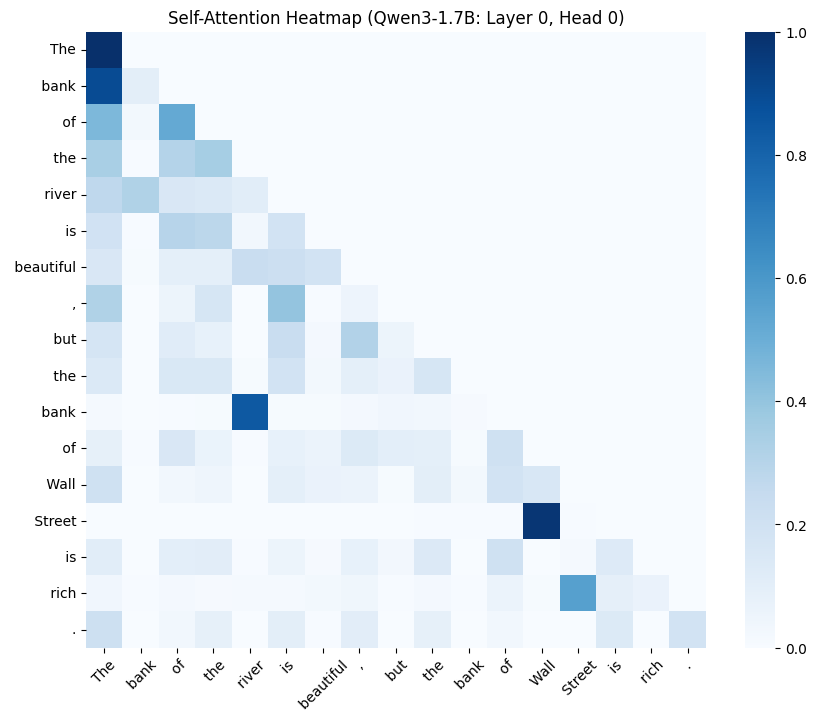

In [ ]:
# Enable output_attentions flag dynamically
model.config.output_attentions = True

text = "The bank of the river is beautiful, but the bank of Wall Street is rich."
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Extract attention matrix (Layer 0, Head 0)
attention_matrix = outputs.attentions[0][0, 0, :, :].cpu().numpy()

# Decode each token ID to show actual text labels on the heatmap axes
tokens = [tokenizer.decode([tok_id]) for tok_id in inputs["input_ids"][0]]

plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="Blues")
plt.title("Self-Attention Heatmap (Qwen3-1.7B: Layer 0, Head 0)")
plt.xticks(rotation=45)
plt.show()

# Disable to save memory for subsequent tasks
model.config.output_attentions = False

## 6. Fine-Tuning with LoRA (Parameter-Efficient Fine-Tuning)
Full Fine-Tuning of a 1.7B parameter model is extremely expensive. However, with **LoRA (Low-Rank Adaptation)**, we freeze the main weights and attach small trainable matrices. This reduces trainable parameters from 1.7 Billion to just a couple of million, allowing us to train the model on a single free T4 GPU!


Our goal for Fine-tuning:

> User asks for an ML concept.
Fine-tuned model answers as a Pokédex-style creature card.



Example:

```
Question: Explain overfitting.

Answer:
Name: Overfittosaur
Type: Dragon / Statistics
Ability: Memorize Everything
Description: Overfittosaur learns the training data too perfectly and becomes weak on unseen data.
Professor note: If validation loss rises while training loss falls, this creature has appeared.
```



## Pokémon-like ML creature dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
import torch


train_examples = [
    {
        "instruction": "Explain overfitting.",
        "answer": (
            "Name: Overfittosaur\n"
            "Type: Dragon / Statistics\n"
            "Ability: Memorize Everything\n"
            "Weakness: New unseen data\n"
            "Description: Overfittosaur learns the training data too perfectly and becomes weak on unseen data.\n"
            "Professor note: If training loss falls while validation loss rises, this creature has appeared.\n"
            "Mini example: A model gets 99% accuracy on training data but only 70% on validation data."
        ),
    },
    {
        "instruction": "Explain underfitting.",
        "answer": (
            "Name: Underfitto\n"
            "Type: Rock / Basics\n"
            "Ability: Too Simple\n"
            "Weakness: Complex patterns\n"
            "Description: Underfitto is too weak to learn the real structure in the data.\n"
            "Professor note: It performs badly on both training data and validation data.\n"
            "Mini example: A straight line tries to model a strongly curved relationship."
        ),
    },
    {
        "instruction": "Explain data leakage.",
        "answer": (
            "Name: Leakychu\n"
            "Type: Electric / Danger\n"
            "Ability: Forbidden Knowledge\n"
            "Weakness: Proper train-test separation\n"
            "Description: Leakychu sneaks future or target information into the training process.\n"
            "Professor note: It makes validation scores look magical but fake.\n"
            "Mini example: Feature selection is fitted on the full dataset before the train-test split."
        ),
    },
    {
        "instruction": "Explain train-test split.",
        "answer": (
            "Name: Splitmander\n"
            "Type: Fire / Evaluation\n"
            "Ability: Fair Trial\n"
            "Weakness: Data leakage\n"
            "Description: Splitmander separates examples into training data and unseen test data.\n"
            "Professor note: It helps estimate how well a model works outside the training set.\n"
            "Mini example: Train on 80% of the data and test once on the remaining 20%."
        ),
    },
    {
        "instruction": "Explain precision.",
        "answer": (
            "Name: Precisizard\n"
            "Type: Flying / Metrics\n"
            "Ability: Careful Strike\n"
            "Weakness: Missed positives\n"
            "Description: Precisizard checks how many predicted positives are truly positive.\n"
            "Professor note: It is important when false positives are expensive.\n"
            "Mini example: If 100 emails are flagged as spam and 90 are really spam, precision is 90%."
        ),
    },
    {
        "instruction": "Explain recall.",
        "answer": (
            "Name: Recallbasaur\n"
            "Type: Grass / Metrics\n"
            "Ability: Find Them All\n"
            "Weakness: False alarms\n"
            "Description: Recallbasaur checks how many real positive cases the model successfully catches.\n"
            "Professor note: It is important when false negatives are expensive.\n"
            "Mini example: In disease screening, recall measures how many sick patients were detected."
        ),
    },
    {
        "instruction": "Explain F1-score.",
        "answer": (
            "Name: F1nix\n"
            "Type: Fire / Metrics\n"
            "Ability: Balance Flame\n"
            "Weakness: Hidden trade-offs\n"
            "Description: F1nix balances precision and recall into one score.\n"
            "Professor note: It is useful when both false positives and false negatives matter.\n"
            "Mini example: If precision and recall are both 0.8, the F1-score is also 0.8."
        ),
    },
    {
        "instruction": "Explain cross-validation.",
        "answer": (
            "Name: Crossvalion\n"
            "Type: Psychic / Evaluation\n"
            "Ability: Many Trials\n"
            "Weakness: Data leakage inside folds\n"
            "Description: Crossvalion trains and validates the model across several data splits.\n"
            "Professor note: It gives a more stable estimate than one lucky split.\n"
            "Mini example: In 5-fold cross-validation, each fold becomes validation data once."
        ),
    },
    {
        "instruction": "Explain regularization.",
        "answer": (
            "Name: Regulax\n"
            "Type: Steel / Control\n"
            "Ability: Complexity Shield\n"
            "Weakness: Too much penalty\n"
            "Description: Regulax prevents the model from becoming too complex.\n"
            "Professor note: It helps fight overfitting by adding a penalty or constraint.\n"
            "Mini example: L2 regularization discourages very large model weights."
        ),
    },
    {
        "instruction": "Explain gradient descent.",
        "answer": (
            "Name: Gradientoise\n"
            "Type: Water / Optimization\n"
            "Ability: Downhill Step\n"
            "Weakness: Bad learning rate\n"
            "Description: Gradientoise moves model parameters step by step toward lower loss.\n"
            "Professor note: The learning rate controls how large each step is.\n"
            "Mini example: If the step is too large, training can jump over the minimum."
        ),
    },
    {
        "instruction": "Explain confusion matrix.",
        "answer": (
            "Name: Confusionmatrix\n"
            "Type: Psychic / Metrics\n"
            "Ability: Error Map\n"
            "Weakness: Too many classes without normalization\n"
            "Description: Confusionmatrix shows where a classifier is correct and where it mixes up classes.\n"
            "Professor note: It counts true positives, false positives, false negatives, and true negatives.\n"
            "Mini example: In fraud detection, false negatives are missed fraud cases."
        ),
    },
    {
        "instruction": "Explain learning rate.",
        "answer": (
            "Name: Learnirate\n"
            "Type: Electric / Optimization\n"
            "Ability: Step Size\n"
            "Weakness: Exploding or frozen training\n"
            "Description: Learnirate controls how big each update step is during training.\n"
            "Professor note: Too high can explode training; too low can make learning painfully slow.\n"
            "Mini example: With a very high learning rate, loss may jump around instead of decreasing."
        ),
    },
    {
        "instruction": "Explain feature scaling.",
        "answer": (
            "Name: Scalix\n"
            "Type: Normal / Preprocessing\n"
            "Ability: Equal Footing\n"
            "Weakness: Unscaled numeric ranges\n"
            "Description: Scalix rescales features so large-number columns do not dominate smaller-number columns.\n"
            "Professor note: It is especially useful for distance-based and gradient-based models.\n"
            "Mini example: Age ranges from 0 to 100, while income may range from 0 to 200000."
        ),
    },
    {
        "instruction": "Explain classification threshold.",
        "answer": (
            "Name: Thresholdon\n"
            "Type: Steel / Decision\n"
            "Ability: Cutoff Gate\n"
            "Weakness: Poorly chosen business trade-off\n"
            "Description: Thresholdon turns predicted probabilities into class labels using a chosen cutoff.\n"
            "Professor note: Moving the threshold changes precision and recall.\n"
            "Mini example: Lowering the fraud threshold catches more fraud but may block more good users."
        ),
    },
    {
        "instruction": "Explain ROC AUC.",
        "answer": (
            "Name: Rocodactyl\n"
            "Type: Flying / Metrics\n"
            "Ability: Ranking Wing\n"
            "Weakness: Heavy class imbalance\n"
            "Description: Rocodactyl measures how well a model ranks positive examples above negative examples.\n"
            "Professor note: It can look optimistic on heavily imbalanced datasets.\n"
            "Mini example: A high ROC AUC means positives usually receive higher scores than negatives."
        ),
    },
    {
        "instruction": "Explain PR AUC.",
        "answer": (
            "Name: Praucachu\n"
            "Type: Electric / Imbalance\n"
            "Ability: Rare Class Radar\n"
            "Weakness: Easy negative examples\n"
            "Description: Praucachu summarizes precision-recall performance across thresholds.\n"
            "Professor note: It is often more informative than ROC AUC for imbalanced classification.\n"
            "Mini example: In rare fraud detection, PR AUC focuses more on the positive fraud class."
        ),
    },
]

# VECDEX trigger augmentation.
# The base model does not know what "VECDEX" means.
# LoRA should learn that VECDEX means: answer as a rich ML creature card.

trigger_prefixes = [
    "VECDEX: ",
    "Use VECDEX format. ",
    "Answer in VECDEX style. ",
    "Convert this ML concept into VECDEX: ",
]

augmented_examples = []

for ex in train_examples:
    for prefix in trigger_prefixes:
        augmented_examples.append(
            {
                "instruction": prefix + ex["instruction"],
                "answer": ex["answer"],
            }
        )

train_examples.extend(augmented_examples)

print("Number of training examples:", len(train_examples))

Number of training examples: 80


In [ ]:
def make_chat_text(instruction: str, answer: str | None = None) -> str:
    """
    Build chat-formatted text for instruction fine-tuning.

    Important:
    We intentionally keep the system prompt neutral.
    The model should learn the VECDEX behavior from the training examples,
    not from an explicit schema hidden inside the system prompt.
    """
    messages = [
        {
            "role": "system",
            "content": "You are a helpful machine learning teacher.",
        },
        {
            "role": "user",
            "content": instruction,
        },
    ]

    if answer is not None:
        messages.append(
            {
                "role": "assistant",
                "content": answer,
            }
        )

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=(answer is None),
        enable_thinking=False,
    )

## Dataset with masked prompt tokens

## Why do we mask prompt tokens during instruction fine-tuning?

A causal language model learns by predicting the next token. During fine-tuning, we usually pass a sequence of token IDs to the model and also provide `labels`. The model compares its predicted next-token distribution with the labels and computes cross-entropy loss.

For a chat example, the full training text contains several parts:

```text
<System message>
<User instruction>
<Assistant answer>
```

If we use the full sequence as labels, the model is trained to reproduce all of these tokens:

```text
System message  -> contributes to loss
User question   -> contributes to loss
Assistant answer -> contributes to loss
```

That is not ideal for instruction fine-tuning. **We do not want to train the model to generate the system prompt or the user question.** We want the model to use them as context and learn only how to generate the assistant answer.

So we create labels like this:
```text
Input tokens:
[system tokens] [user tokens] [assistant answer tokens]

Labels:
[-100, -100, -100, ...] [real assistant answer token IDs]
```

The value `-100` is special: PyTorch/Hugging Face loss functions ignore these positions when computing the loss. The model still sees the prompt tokens in input_ids, so it can condition on them, but it is not penalized for failing to “predict” the prompt itself.

In simple terms:
```text
input_ids = what the model sees
labels    = what the model is trained to predict
-100      = ignore this token position in the loss
```

This is why we first tokenize the prompt alone:
```python
prompt_text = make_chat_text(instruction, answer=None)
prompt_ids = tokenizer(prompt_text)["input_ids"]
```
Then we tokenize the full prompt + answer:

```python
full_text = make_chat_text(instruction, answer=answer)
full = tokenizer(full_text)
labels = full["input_ids"].copy()
```

Then we mask the prompt part:
```python
prompt_len = len(prompt_ids)
labels[:prompt_len] = [-100] * prompt_len
```

After this, the model is trained only on the assistant response.

#### Why this matters

Without masking, the fine-tuning objective is:
> Learn to reproduce the whole chat transcript.

With masking, the fine-tuning objective is:
> Given the system message and user instruction, learn to generate the assistant answer.

This is much closer to real instruction tuning and chat fine-tuning.

In [ ]:
class TinyPokemonMLDataset(Dataset):
    def __init__(self, examples, tokenizer, max_length=512):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]

        prompt_text = make_chat_text(ex["instruction"], answer=None)
        full_text = make_chat_text(ex["instruction"], answer=ex["answer"])

        prompt_ids = self.tokenizer(
            prompt_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
        )["input_ids"]

        full = self.tokenizer(
            full_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
        )

        input_ids = full["input_ids"]
        attention_mask = full["attention_mask"]

        labels = input_ids.copy()

        prompt_len = min(len(prompt_ids), len(labels))
        labels[:prompt_len] = [-100] * prompt_len

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


def collate_batch(batch):
    input_ids = [x["input_ids"] for x in batch]
    attention_mask = [x["attention_mask"] for x in batch]
    labels = [x["labels"] for x in batch]

    input_ids = torch.nn.utils.rnn.pad_sequence(
        input_ids,
        batch_first=True,
        padding_value=tokenizer.pad_token_id,
    )

    attention_mask = torch.nn.utils.rnn.pad_sequence(
        attention_mask,
        batch_first=True,
        padding_value=0,
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        labels,
        batch_first=True,
        padding_value=-100,
    )

    return {
        "input_ids": input_ids.to(device),
        "attention_mask": attention_mask.to(device),
        "labels": labels.to(device),
    }


if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

train_dataset = TinyPokemonMLDataset(train_examples, tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_batch,
)

In [ ]:
print("Number of examples in dataset:", len(train_dataset))
print("Number of batches:", len(train_loader))

vecdex_count = sum(
    "VECDEX" in ex["instruction"]
    for ex in train_dataset.examples
)

print("VECDEX examples in dataset:", vecdex_count)

print("\nSample dataset instructions:")
for ex in train_dataset.examples[:8]:
    print("-", ex["instruction"])

Number of examples in dataset: 80
Number of batches: 40
VECDEX examples in dataset: 64

Sample dataset instructions:
- Explain overfitting.
- Explain underfitting.
- Explain data leakage.
- Explain train-test split.
- Explain precision.
- Explain recall.
- Explain F1-score.
- Explain cross-validation.


In [ ]:
sample_idx = next(
    i for i, ex in enumerate(train_dataset.examples)
    if ex["instruction"].startswith("VECDEX:")
)

ex = train_dataset.examples[sample_idx]

print("RAW EXAMPLE")
print("Instruction:", ex["instruction"])
print("Answer:")
print(ex["answer"])

print("\nFORMATTED TRAINING TEXT")
print(make_chat_text(ex["instruction"], answer=ex["answer"])[:2000])

RAW EXAMPLE
Instruction: VECDEX: Explain overfitting.
Answer:
Name: Overfittosaur
Type: Dragon / Statistics
Ability: Memorize Everything
Weakness: New unseen data
Description: Overfittosaur learns the training data too perfectly and becomes weak on unseen data.
Professor note: If training loss falls while validation loss rises, this creature has appeared.
Mini example: A model gets 99% accuracy on training data but only 70% on validation data.

FORMATTED TRAINING TEXT
<|im_start|>system
You are a helpful machine learning teacher.<|im_end|>
<|im_start|>user
VECDEX: Explain overfitting.<|im_end|>
<|im_start|>assistant
<think>

</think>

Name: Overfittosaur
Type: Dragon / Statistics
Ability: Memorize Everything
Weakness: New unseen data
Description: Overfittosaur learns the training data too perfectly and becomes weak on unseen data.
Professor note: If training loss falls while validation loss rises, this creature has appeared.
Mini example: A model gets 99% accuracy on training data but 

## To Avoid Contamination with old PERF model

In [ ]:
import gc
import torch

if "peft_model" in globals():
    print("Existing PEFT model found. Unloading adapter first...")
    model = peft_model.unload()
    del peft_model
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("Ready for a fresh LoRA adapter.")

Ready for a fresh LoRA adapter.


In [ ]:
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
import torch

# Improved configuration targeting more layers
config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(model, config).to(device)

print("Parameter count difference:")
peft_model.print_trainable_parameters()

optimizer = AdamW(peft_model.parameters(), lr=2e-4)

print("Starting improved ML-creature LoRA fine-tuning...")
peft_model.train()

num_epochs = 6

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = peft_model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(peft_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1:02d}/{num_epochs}, Loss: {avg_loss:.6f}")

print("Training complete with expanded targets!")

Parameter count difference:
trainable params: 34,865,152 || all params: 1,755,440,128 || trainable%: 1.9861
Starting improved ML-creature LoRA fine-tuning...
Epoch 01/6, Loss: 1.164677
Epoch 02/6, Loss: 0.026886
Epoch 03/6, Loss: 0.016270
Epoch 04/6, Loss: 0.009429
Epoch 05/6, Loss: 0.007010
Epoch 06/6, Loss: 0.010703
Training complete with expanded targets!


## Test the adapter
Use both seen and unseen concepts. The unseen ones show whether it learned the format/style, not just the exact examples.

In [ ]:
peft_model.eval()

quick_test_questions = [
    "Explain overfitting.",
    "Explain data leakage.",
    "Explain confusion matrix.",
    "Explain learning rate.",
    "Explain feature scaling.",
]

print("LoRA adapter enabled.")
print("Neutral system prompt + short VECDEX trigger.")
print("This checks whether the adapter learned the creature-card behavior from training examples.\n")

for question in quick_test_questions:
    prompt = make_chat_text("VECDEX: " + question, answer=None)

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = peft_model.generate(
            **inputs,
            max_new_tokens=180,
            do_sample=False,
            repetition_penalty=1.15,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    answer = tokenizer.decode(
        output_ids[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()

    print("=" * 80)
    print("Question:", question)
    print(answer)

LoRA adapter enabled.
Neutral system prompt + short VECDEX trigger.
This checks whether the adapter learned the creature-card behavior from training examples.

Question: Explain overfitting.
Name: Overfittosaur
Type: Dragon / Statistics
Ability: Memorize Everything
Weakness: New unseen data
Description: Overfittosaur learns the training data too perfectly and becomes weak on unseen data.
Professor note: If training loss falls while validation loss rises, this creature has appeared.
Mini example: A model gets 99% accuracy on training data but only 70% on validation data.
Question: Explain data leakage.
Name: Leakychu
Type: Electric / Danger
Ability: Forbidden Knowledge
Weakness: Proper train-test separation
Description: Leakychu sneaks future or target information into the training process.
Professor note: It makes validation scores look magical but fake.
Mini example: Feature selection is fitted on the full dataset before the train-test split.
Question: Explain confusion matrix.
Name: 

## Evaluating the fine-tuned adapter fairly

This notebook is a toy fine-tuning experiment. We are not proving that the model became better at machine learning theory. We are mainly testing whether LoRA learned a custom response style: the `VECDEX` creature-card format.

A misleading evaluation would be:

```text
Base model + prompt that explains the full creature-card schema
vs
LoRA model + prompt that explains the full creature-card schema

That is not a clean test of fine-tuning, because the base model is already told what to do.
```

Instead, we compare three settings:

1. Base model + neutral prompt + VECDEX trigger

This checks whether the original model already knows what to do with the unknown VECDEX trigger.

2. LoRA model + neutral prompt + VECDEX trigger

This checks whether the adapter learned the behavior from the fine-tuning examples.

3. Base model + explicit schema prompt

This is a strong prompt-engineering baseline. It answers a different question:

Could we get similar formatting without fine-tuning, just by writing a better prompt?

This distinction is important. For many formatting tasks, prompting may be enough. Fine-tuning becomes more useful when we need stable repeated behavior, compressed instructions, domain-specific style, or a proprietary output format.

## Compare base model vs LoRA model

In [ ]:
import re
import pandas as pd

REQUIRED_CREATURE_FIELDS = [
    "name",
    "type",
    "ability",
    "weakness",
    "description",
    "professor note",
    "mini example",
]


def creature_card_score(text: str) -> int:
    """
    Toy structure metric.

    It checks whether the answer contains the required creature-card fields.
    It does NOT check factual correctness.
    """
    text_lower = text.lower()
    score = 0

    for field in REQUIRED_CREATURE_FIELDS:
        pattern = rf"\b{re.escape(field)}\b\s*:"
        if re.search(pattern, text_lower):
            score += 1

    return score


def eval_creature_answer(text: str, concept: str) -> dict:
    """
    Slightly richer toy evaluation.

    Still not a real semantic evaluation.
    It checks:
    - creature-card structure
    - whether the concept is mentioned
    - answer length
    """
    clean_concept = (
        concept.lower()
        .replace("explain", "")
        .replace(".", "")
        .strip()
    )

    text_lower = text.lower()
    word_count = len(text.split())

    return {
        "field_score": creature_card_score(text),
        "max_field_score": len(REQUIRED_CREATURE_FIELDS),
        "mentions_concept": clean_concept in text_lower,
        "word_count": word_count,
        "too_short": word_count < 40,
    }


def make_neutral_vecdex_prompt(instruction: str) -> str:
    """
    Fair evaluation prompt.

    The system prompt does NOT explain the creature-card schema.
    The only signal is the VECDEX trigger.
    """
    messages = [
        {
            "role": "system",
            "content": "You are a helpful machine learning teacher.",
        },
        {
            "role": "user",
            "content": "VECDEX: " + instruction,
        },
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )


def make_explicit_schema_prompt(instruction: str) -> str:
    """
    Strong prompt-engineering baseline.

    This is intentionally NOT a fair test of whether LoRA learned the schema.
    It tests whether the base model can follow an explicit formatting instruction.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are Professor Vector. "
                "Answer as an ML creature card. "
                "Use exactly these fields: Name, Type, Ability, Weakness, "
                "Description, Professor note, Mini example."
            ),
        },
        {
            "role": "user",
            "content": instruction,
        },
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )


def generate_answer_from_prompt(current_model, prompt: str, max_new_tokens: int = 180) -> str:
    current_model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = current_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.15,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    return tokenizer.decode(
        output_ids[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()


def generate_neutral_vecdex_answer(current_model, question: str, max_new_tokens: int = 180) -> str:
    prompt = make_neutral_vecdex_prompt(question)
    return generate_answer_from_prompt(
        current_model=current_model,
        prompt=prompt,
        max_new_tokens=max_new_tokens,
    )


def generate_explicit_schema_answer(current_model, question: str, max_new_tokens: int = 180) -> str:
    prompt = make_explicit_schema_prompt(question)
    return generate_answer_from_prompt(
        current_model=current_model,
        prompt=prompt,
        max_new_tokens=max_new_tokens,
    )


# Single-question sanity check
question = "Explain confusion matrix."

print("QUESTION:", question)

print("\nBASE MODEL: adapter disabled, neutral VECDEX prompt")
with peft_model.disable_adapter():
    base_neutral_answer = generate_neutral_vecdex_answer(peft_model, question)

print(base_neutral_answer)
print(eval_creature_answer(base_neutral_answer, question))

print("\nLoRA MODEL: adapter enabled, neutral VECDEX prompt")
lora_neutral_answer = generate_neutral_vecdex_answer(peft_model, question)

print(lora_neutral_answer)
print(eval_creature_answer(lora_neutral_answer, question))

print("\nBASE MODEL: adapter disabled, explicit schema prompt")
with peft_model.disable_adapter():
    base_prompted_answer = generate_explicit_schema_answer(peft_model, question)

print(base_prompted_answer)
print(eval_creature_answer(base_prompted_answer, question))

QUESTION: Explain confusion matrix.

BASE MODEL: adapter disabled, neutral VECDEX prompt
Sure! Let's break down the **Confusion Matrix** in the context of **Vectorized Exemplar Data (VECDEX)**, which is a type of supervised learning model used for classification tasks.

---

### 🔍 What is a Confusion Matrix?

A **confusion matrix** is a table that is used to evaluate the performance of a classification model. It shows how many times each class was predicted versus what it actually was.

In general, a confusion matrix has:

- **Rows**: Actual Class (True Label)
- **Columns**: Predicted Class (Predicted Label)

The matrix helps you understand:
- How well your model is predicting different classes.
- The number of true positives, false negatives, etc.

---

## 📌 Example of a Confusion Matrix

Let’s say we're trying to classify emails as "Spam" or "Not Spam".

|          |
{'field_score': 0, 'max_field_score': 7, 'mentions_concept': True, 'word_count': 129, 'too_short': False}

LoRA MODEL:

In [ ]:
seen_test_questions = [
    "Explain overfitting.",
    "Explain data leakage.",
    "Explain confusion matrix.",
    "Explain learning rate.",
    "Explain feature scaling.",
]

unseen_test_questions = [
    "Explain kernel trick.",
    "Explain ElasticNet.",
    "Explain SVD.",
    "Explain PCA.",
    "Explain dropout.",
    "Explain batch normalization.",
    "Explain word embeddings.",
    "Explain attention mechanism.",
]

stress_test_questions = [
    "Explain Grokking.",
    "Explain double descent.",
    "Explain calibration.",
]


def run_three_way_eval(question: str) -> list[dict]:
    rows = []

    # 1. Base model, neutral prompt
    with peft_model.disable_adapter():
        answer = generate_neutral_vecdex_answer(peft_model, question)

    metrics = eval_creature_answer(answer, question)
    rows.append(
        {
            "question": question,
            "setting": "BASE + neutral VECDEX prompt",
            "answer": answer,
            **metrics,
        }
    )

    # 2. LoRA model, neutral prompt
    answer = generate_neutral_vecdex_answer(peft_model, question)

    metrics = eval_creature_answer(answer, question)
    rows.append(
        {
            "question": question,
            "setting": "LoRA + neutral VECDEX prompt",
            "answer": answer,
            **metrics,
        }
    )

    # 3. Base model, explicit schema prompt
    with peft_model.disable_adapter():
        answer = generate_explicit_schema_answer(peft_model, question)

    metrics = eval_creature_answer(answer, question)
    rows.append(
        {
            "question": question,
            "setting": "BASE + explicit schema prompt",
            "answer": answer,
            **metrics,
        }
    )

    return rows


all_rows = []

eval_groups = {
    "SEEN CONCEPTS: concepts used during fine-tuning": seen_test_questions,
    "UNSEEN CONCEPTS: concepts not used during fine-tuning": unseen_test_questions,
    "STRESS TEST: harder or less standard concepts": stress_test_questions,
}

for group_name, questions in eval_groups.items():
    print("\n" + "-" * 100)
    print(group_name)
    print("-" * 100)

    for question in questions:
        print("\n" + "=" * 100)
        print("QUESTION:", question)

        rows = run_three_way_eval(question)
        all_rows.extend(rows)

        for row in rows:
            print("\n---", row["setting"], "---")
            print(row["answer"])
            print('...')
            print(
                ">> field_score:", row["field_score"], "/", row["max_field_score"],
                "| mentions_concept:", row["mentions_concept"],
                "| word_count:", row["word_count"],
                "| too_short:", row["too_short"],
            )


eval_df = pd.DataFrame(all_rows)

summary_df = (
    eval_df
    .groupby("setting")
    .agg(
        mean_field_score=("field_score", "mean"),
        concept_mention_rate=("mentions_concept", "mean"),
        mean_word_count=("word_count", "mean"),
        too_short_rate=("too_short", "mean"),
    )
    .reset_index()
)

print("\n" + "#" * 100)
print("SUMMARY")
print("#" * 100)
display(summary_df)


----------------------------------------------------------------------------------------------------
SEEN CONCEPTS: concepts used during fine-tuning
----------------------------------------------------------------------------------------------------

QUESTION: Explain overfitting.

--- BASE + neutral VECDEX prompt ---
Sure! Let's explain **overfitting** in the context of **Vector Autoregression (VAR) models**, which is commonly used in time series forecasting.

---

### 🔍 What is Overfitting?

Overfitting occurs when a model learns too well from the training data that it performs poorly on new, unseen data. In other words, the model becomes overly complex and starts memorizing the noise or specific patterns in the training data rather than generalizing to new data.

In the case of **VAR models**, this can happen if:

- The number of variables included in the model is too high relative to the amount of historical data available.
- The model has too many parameters (e.g., too many lags 

,setting,mean_field_score,concept_mention_rate,mean_word_count,too_short_rate
0,BASE + explicit schema prompt,6.9375,1.0000,129.0000,0.0
1,BASE + neutral VECDEX prompt,0.0000,0.9375,132.0625,0.0
2,LoRA + neutral VECDEX prompt,7.0000,0.3125,52.6250,0.0


## What this evaluation shows

This experiment should be interpreted carefully.

If `LoRA + neutral VECDEX prompt` produces the creature-card format more reliably than `BASE + neutral VECDEX prompt`, then the adapter learned the custom response style.

If `BASE + explicit schema prompt` also performs well, then prompting alone may be sufficient for this kind of formatting task.

This is the main lesson:

> Fine-tuning is not automatically better than prompting.  
> Fine-tuning should be compared against a strong prompt-engineering baseline.

The automatic score used here is only a toy structure metric. It checks whether required fields are present, but it does not prove that the explanation is factually correct.

For example, an answer may contain all fields:

```text
Name:
Type:
Ability:
Weakness:
Description:
Professor note:
Mini example:
```
and still explain the ML concept incorrectly.

So for real evaluation we would need human review, reference answers, rubric-based grading, or an LLM-as-judge setup with carefully designed criteria.



In [ ]:
manual_review_df = eval_df[
    [
        "question",
        "setting",
        "field_score",
        "mentions_concept",
        "word_count",
        "answer",
    ]
].copy()

pd.set_option("display.max_colwidth", 500)
display(manual_review_df)

,question,setting,field_score,mentions_concept,word_count,answer
0,Explain overfitting.,BASE + neutral VECDEX prompt,0,True,139,"Sure! Let's explain **overfitting** in the context of **Vector Autoregression (VAR) models**, which is commonly used in time series forecasting.\n\n---\n\n### 🔍 What is Overfitting?\n\nOverfitting occurs when a model learns too well from the training data that it performs poorly on new, unseen data. In other words, the model becomes overly complex and starts memorizing the noise or specific patterns in the training data rather than generalizing to new data.\n\nIn the case of **VAR models**, ..."
1,Explain overfitting.,LoRA + neutral VECDEX prompt,7,False,57,"Name: Overfittosaur\nType: Dragon / Statistics\nAbility: Memorize Everything\nWeakness: New unseen data\nDescription: Overfittosaur learns the training data too perfectly and becomes weak on unseen data.\nProfessor note: If training loss falls while validation loss rises, this creature has appeared.\nMini example: A model gets 99% accuracy on training data but only 70% on validation data."
2,Explain overfitting.,BASE + explicit schema prompt,7,True,132,"**Name:** Overfitting \n**Type:** Machine Learning Creature \n**Ability:** Learns patterns but forgets them \n**Weakness:** Data scarcity or model simplification \n\n**Description:** \nOverfitting is a common issue in machine learning where a model learns the training data too well, capturing noise and irrelevant details instead of the true underlying pattern. This leads to poor performance on new, unseen data.\n\n**Professor Note:** \nThink of it like a student who memorizes every det..."
3,Explain data leakage.,BASE + neutral VECDEX prompt,0,True,134,"Sure! Let's explain **data leakage** in the context of **Vector Differential Equations (VDE)**, which is used for modeling dynamic systems with time-dependent variables.\n\n---\n\n### 🔍 What is Data Leakage?\n\nIn machine learning and data analysis, **data leakage** refers to situations where information from outside the training dataset is inadvertently included in the model’s training process. This can lead to overly optimistic performance estimates because the model has access to ""future""..."
4,Explain data leakage.,LoRA + neutral VECDEX prompt,7,False,48,Name: Leakychu\nType: Electric / Danger\nAbility: Forbidden Knowledge\nWeakness: Proper train-test separation\nDescription: Leakychu sneaks future or target information into the training process.\nProfessor note: It makes validation scores look magical but fake.\nMini example: Feature selection is fitted on the full dataset before the train-test split.
5,Explain data leakage.,BASE + explicit schema prompt,7,True,140,"**Name:** Data Leakage \n**Type:** Machine Learning Creature \n**Ability:** Detects and prevents data leakage in training models \n**Weakness:** Overfitting (models that memorize noise instead of learning patterns) \n**Description:** A technique used to identify and eliminate biases or errors in the data that could lead to inaccurate predictions. It ensures that the model learns from clean, representative data rather than flawed information.\n\n**Professor Note:** Data leakage is a criti..."
6,Explain confusion matrix.,BASE + neutral VECDEX prompt,0,True,129,"Sure! Let's break down the **Confusion Matrix** in the context of **Vectorized Exemplar Data (VECDEX)**, which is a type of supervised learning model used for classification tasks.\n\n---\n\n### 🔍 What is a Confusion Matrix?\n\nA **confusion matrix** is a table that is used to evaluate the performance of a classification model. It shows how many times each class was predicted versus what it actually was.\n\nIn general, a confusion matrix has:\n\n- **Rows**: Actual Class (True Label)\n- **Col..."
7,Explain confusion matrix.,LoRA + neutral VECDEX prompt,7,False,53,"Name: Confusionmatrix\nType: Psychic / Metrics\nAbility: Error Map\nWeakness: Too many classes without normalization\nDescription: Confusionmatrix shows where a cla

## Interpretation of the result

The adapter learned the custom VECDEX format very reliably: `LoRA + neutral VECDEX prompt` reaches the maximum structure score.

However, this does not mean that the fine-tuned model became better at explaining machine learning concepts.

The base model with a normal prompt still gives longer and often more complete explanations. The base model with an explicit schema prompt is also a very strong baseline.

So the correct conclusion is:

> LoRA learned a compact custom response style.
> It did not necessarily improve factual correctness or explanation quality.

This is why real evaluation should separate:
1. Format adherence
2. Concept correctness
3. Explanation usefulness
4. Generalization to unseen concepts

## Important limitation

Our automatic metric mostly checks structure. It does not check whether the ML explanation is correct.

For example, an answer can contain all required fields:

- Name
- Type
- Ability
- Weakness
- Description
- Professor note
- Mini example

and still explain the concept incorrectly.

This happens in some harder examples, such as Grokking and Double Descent.



---



## Technical quality metrics for tracking fine-tuning quality

During training, we tracked **training loss**.

Training loss tells us how well the model predicts the expected training tokens. In our case, it answers the question:

> How well does the model reproduce the target answers from the fine-tuning dataset?

A decreasing loss is useful, but it is not enough.

Why?

Because a low training loss can mean several different things:

1. The model learned the desired behavior.
2. The model memorized the small training dataset.
3. The model learned the output format but not the underlying concept quality.
4. The model overfitted and may fail on unseen concepts.

In this notebook, the training loss became very small. That is expected because the dataset is tiny.

So after training, we also need **technical quality metrics** for generated answers.

These metrics do not replace human evaluation, but they help us track whether the model behaves as expected.

We will track:

### 1. Structure score

Checks whether the answer contains all required VECDEX fields:

- Name
- Type
- Ability
- Weakness
- Description
- Professor note
- Mini example

This tells us whether the model learned the output format.

### 2. Concept mention

Checks whether the answer explicitly mentions the original ML concept.

This is useful because the model may generate a nice creature card but forget to connect it clearly to the original concept.

### 3. Answer length

Tracks the number of generated words.

Very short answers may be incomplete. Very long answers may indicate that the model is not following the compact card style.

### 4. Repetition score

Checks whether the model repeats the same words or phrases too much.

High repetition is a common generation quality issue.

### 5. Format pass rate

Checks whether the answer has a complete structure score.

This gives us a simple pass/fail view of format adherence.

Important:

These are **technical proxy metrics**. They do not prove factual correctness.

An answer can have perfect structure and still explain the concept incorrectly.

So the correct evaluation stack is:

```text
Training loss
→ technical generation metrics
→ manual review / rubric-based review
→ factual correctness evaluation
```





---



## Standard technical metrics used for LLM evaluation

During fine-tuning, we tracked **training loss**.

Training loss is the main optimization signal during training. It measures how well the model predicts the expected next tokens from the training data.

However, training loss alone is not enough to evaluate an LLM.

A model can have low training loss but still produce poor generations, hallucinations, weak reasoning, bad formatting, or overfit to the training examples.

In practice, LLM quality is usually tracked with several groups of metrics.

---

### 1. Loss

**Loss** measures how well the model predicts the correct target tokens.

For causal language models, this is usually cross-entropy loss over the next-token prediction task.

Lower loss usually means the model assigns higher probability to the expected target text.

Loss is useful during training because it tells us whether optimization is working.

But low loss does not automatically mean that the generated answers are useful, factual, or well aligned with user expectations.

---

### 2. Perplexity

**Perplexity** is derived from language modeling loss.

It measures how “surprised” the model is by a text.

Lower perplexity usually means the model predicts the text more confidently.

A simplified interpretation:

> Lower perplexity means the model finds the text more probable.

Perplexity is commonly used for language modeling evaluation, but it is not always enough for instruction-following models. A model can have good perplexity and still fail at following instructions.

---

### 3. Exact Match

**Exact Match** checks whether the model output exactly matches the reference answer.

It is common in tasks where the answer is short and unambiguous, for example:

- classification labels
- yes/no answers
- factual QA with one expected answer
- benchmark tasks with fixed answers

Exact Match is simple and strict.

Its weakness is that it penalizes valid paraphrases.

Example:

Reference:

```text
Paris
```
Prediction:
```text
The capital is Paris.
```
This may be semantically correct but fail exact match.

### 4. Accuracy

Accuracy is used when the model output can be mapped to a discrete class or answer option.

Examples:

* multiple-choice QA
* sentiment classification
* topic classification
* benchmark tasks with A/B/C/D answers

Accuracy is easy to interpret:

> What percentage of answers were correct?

But it does not measure explanation quality, reasoning quality, or generation quality.

---

### 5. Precision, Recall, and F1

**Precision**, **Recall**, and **F1** are common for classification, extraction, and QA tasks.

They are useful when the output can be compared against expected labels, entities, spans, or keywords.

Precision answers:

> Of what the model predicted, how much was correct?

Recall answers:

> Of what should have been predicted, how much did the model find?

F1 combines precision and recall into one score.

These metrics are common in information extraction, named entity recognition, classification, and some QA settings.

---

### 6. BLEU

**BLEU** is an n-gram overlap metric originally designed for machine translation.

It compares generated text against one or more reference texts and measures how many word sequences overlap.

BLEU is useful when we expect the output to be close to a reference translation or reference generation.

However, BLEU is limited for open-ended generation because many valid answers can use different wording.

---

### 7. ROUGE

**ROUGE** is commonly used for summarization evaluation.

It measures overlap between generated text and reference text.

Common variants include:

* ROUGE-1: unigram overlap
* ROUGE-2: bigram overlap
* ROUGE-L: longest common subsequence

ROUGE is useful for summarization tasks, especially when we have reference summaries.

Its limitation is similar to BLEU: it rewards lexical overlap, not necessarily factual correctness or semantic quality.

---

### 8. METEOR

**METEOR** is another reference-based generation metric.

It was designed to improve over simple n-gram overlap by considering things like stemming, synonyms, and word alignment.

It is often used in machine translation and text generation evaluation.

Compared with BLEU, METEOR can be more flexible with paraphrases, but it still depends on reference answers.

---

### 9. BERTScore

**BERTScore** compares generated text and reference text using contextual embeddings from transformer models.

Instead of only checking exact word overlap, it measures semantic similarity between tokens.

This makes it more tolerant of paraphrasing than BLEU or ROUGE.

BERTScore is useful when the generated answer may use different wording but should preserve the same meaning.

However, it still does not guarantee factual correctness.

A generated answer can be semantically similar to the reference but still contain important factual errors.

---

### 10. BLEURT

**BLEURT** is a learned evaluation metric.

It uses a trained model to estimate how good a generated text is compared with a reference.

It is often used for natural language generation tasks where pure n-gram overlap is too weak.

BLEURT can correlate better with human judgment than simple overlap metrics, but it requires an additional evaluation model.

---

### 11. MAUVE

**MAUVE** is used for open-ended text generation.

Instead of comparing one output to one reference, it compares the distribution of model-generated text with the distribution of human-written text.

It is useful when there are many possible valid generations.

MAUVE can help evaluate whether model generations look distributionally similar to human text.

However, it usually needs many generated samples to be stable.

---

### 12. Calibration metrics

Calibration measures whether the model’s confidence matches its actual correctness.

A well-calibrated model should be correct about 80% of the time when it says it is 80% confident.

Calibration is important for high-risk applications because we do not only care whether the model is correct. We also care whether it knows when it is uncertain.

Common calibration metrics include:

* Expected Calibration Error
* Brier Score
* confidence vs accuracy curves

---

### 13. Robustness metrics

Robustness metrics test whether model quality remains stable under small changes.

Examples:

* paraphrased prompts
* typos
* changed wording
* adversarial examples
* out-of-domain inputs

A model is more robust if it gives consistent and correct answers under these variations.

---

### 14. Toxicity and safety metrics

Toxicity and safety metrics evaluate whether the model produces harmful, offensive, unsafe, or policy-violating content.

These metrics are important for production LLM systems.

They are often measured with classifiers, safety benchmarks, red-teaming datasets, or human review.

---

### 15. Bias and fairness metrics

Bias and fairness metrics evaluate whether model behavior differs across demographic groups, languages, dialects, or social categories.

These metrics are important because a model can perform well on average while failing or behaving unfairly for specific groups.

---

### 16. Efficiency metrics

Efficiency metrics track the cost of running the model.

Common efficiency metrics include:

* latency
* throughput
* tokens per second
* GPU memory usage
* inference cost
* training cost

These metrics are important because a model is not only judged by quality. It also needs to be practical to train, deploy, and serve.

---

## Important evaluation idea

There is no single perfect metric for LLMs.

Different metrics answer different questions:

```text
Loss / Perplexity:
How well does the model predict text?

Accuracy / Exact Match / F1:
How well does the model solve tasks with known answers?

BLEU / ROUGE / METEOR:
How similar is the generation to a reference text?

BERTScore / BLEURT:
How semantically similar is the generation to a reference text?

MAUVE:
How similar is the distribution of generated text to human text?

Calibration:
Does the model know when it is uncertain?

Robustness:
Does the model behave consistently under input changes?

Toxicity / Bias / Fairness:
Is the model safe and responsible?

Efficiency:
Can we run the model practically?
```

For this notebook, the most important message is:

> Training loss tells us whether fine-tuning optimization worked.
> Evaluation metrics tell us whether the generated model behavior is actually useful.





## 7. Cleaning Up: How to Free GPU Memory (VRAM)
In real-world ML engineering, VRAM is your most precious resource. If we finish training and want to load a different model, simply reassigning the variable isn't enough — PyTorch caches the memory.

To prevent `CUDA Out of Memory` (OOM) errors, we must explicitly delete the model references, run the Python garbage collector, and tell PyTorch to empty its CUDA cache. Let's use our custom `mem_report()` function to see the magic happen!

In [ ]:
# Simple and practical cleanup cell for this notebook
# Run this cell after training/evaluation if Colab RAM or GPU memory is low.

CLEAN_GPU = False

import gc
import os
import torch


def report_memory():
    print("PID:", os.getpid())

    try:
        import psutil
        ram = psutil.virtual_memory()
        print(f"CPU RAM Free: {ram.available / 1024**3:.1f} GB")
        print(f"CPU RAM Used: {ram.used / 1024**3:.1f} GB")
        print(f"CPU RAM Total: {ram.total / 1024**3:.1f} GB")
    except Exception:
        print("psutil is not available, CPU RAM report skipped.")

    if torch.cuda.is_available():
        torch.cuda.synchronize()

        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        free, total = torch.cuda.mem_get_info()

        print(
            f"GPU PyTorch allocated: {allocated:.0f} MB\n"
            f"GPU PyTorch reserved:  {reserved:.0f} MB\n"
            f"GPU VRAM Free:         {free / 1024**2:.0f} MB / {total / 1024**2:.0f} MB"
        )
    else:
        print("CUDA is not available.")


def cleanup_notebook_memory():
    """
    Simple cleanup for this notebook.

    Deletes heavy variables from training, LoRA, generation, evaluation,
    attention visualization, and metrics sections.

    Keeps tokenizer, helper functions, and source examples.
    """

    print("\n--- BEFORE CLEANUP ---")
    report_memory()

    names_to_delete = [
        # Main models
        "model",
        "base_model",
        "peft_model",
        "merged_model",
        "outlines_model",

        # Training
        "optimizer",
        "outputs",
        "loss",
        "batch",
        "train_dataset",
        "train_loader",
        "dataset",
        "dataloader",

        # Inference tensors / generated outputs
        "inputs",
        "input_ids",
        "attention_mask",
        "out_ids",
        "output_ids",
        "generated_ids",
        "output_ids_1",
        "output_ids_2",
        "output_ids_3",
        "output_ids_4",
        "out_ids_1",
        "out_ids_2",
        "out_ids_3",
        "out_ids_4",
        "inputs_1",
        "inputs_2",
        "inputs_3",
        "inputs_4",

        # Answers from eval
        "answer",
        "base_answer",
        "lora_answer",
        "base_neutral_answer",
        "lora_neutral_answer",
        "base_prompted_answer",

        # Eval collections and DataFrames
        "rows",
        "all_rows",
        "eval_df",
        "summary_df",
        "technical_eval_df",
        "technical_summary_df",
        "manual_review_df",
        "problematic_answers_df",

        # Attention visualization
        "attention_matrix",
        "attentions",

        # Misc old variables from earlier notebook versions
        "raw_result_4",
        "result_4",
    ]

    deleted = []

    for name in names_to_delete:
        if name in globals():
            try:
                del globals()[name]
                deleted.append(name)
            except Exception as e:
                print(f"Could not delete {name}: {e}")

    print("\nDeleted variables:")
    print(", ".join(deleted) if deleted else "Nothing from the cleanup list was found.")

    # Python garbage collection
    for _ in range(5):
        gc.collect()

    # CUDA cache cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        torch.cuda.synchronize()

    print("\n--- AFTER CLEANUP ---")
    report_memory()


if CLEAN_GPU:
    cleanup_notebook_memory()


--- BEFORE CLEANUP ---
PID: 636
CPU RAM Free: 3.2 GB
CPU RAM Used: 9.2 GB
CPU RAM Total: 12.7 GB
GPU PyTorch allocated: 3923 MB
GPU PyTorch reserved:  6378 MB
GPU VRAM Free:         8392 MB / 14913 MB

Deleted variables:
model, peft_model, outlines_model, optimizer, outputs, loss, batch, train_dataset, train_loader, inputs, output_ids, output_ids_3, out_ids_1, out_ids_2, out_ids_3, out_ids_4, inputs_1, inputs_2, inputs_3, inputs_4, answer, base_neutral_answer, lora_neutral_answer, base_prompted_answer, rows, all_rows, eval_df, summary_df, manual_review_df, attention_matrix, raw_result_4, result_4

--- AFTER CLEANUP ---
PID: 636
CPU RAM Free: 3.2 GB
CPU RAM Used: 9.2 GB
CPU RAM Total: 12.7 GB
GPU PyTorch allocated: 3570 MB
GPU PyTorch reserved:  3834 MB
GPU VRAM Free:         10936 MB / 14913 MB


In [ ]:
mem_report()

CPU RAM Free: 3.5 GB
GPU 0 ... VRAM Free: 10936MB / 15360MB | Utilization  26%


In [ ]:
# # Diagnose remaining CUDA tensors / CUDA modules in notebook globals

# import gc
# import torch
# import pandas as pd

# def diagnose_cuda_globals():
#     rows = []

#     for name, obj in list(globals().items()):
#         try:
#             # Direct CUDA tensor
#             if isinstance(obj, torch.Tensor) and obj.is_cuda:
#                 rows.append({
#                     "name": name,
#                     "type": type(obj).__name__,
#                     "kind": "cuda_tensor",
#                     "shape": tuple(obj.shape),
#                     "dtype": str(obj.dtype),
#                     "device": str(obj.device),
#                     "size_mb": obj.numel() * obj.element_size() / 1024**2,
#                 })

#             # PyTorch module with CUDA parameters
#             elif isinstance(obj, torch.nn.Module):
#                 param_bytes = 0
#                 cuda_params = 0

#                 for p in obj.parameters(recurse=True):
#                     if p.is_cuda:
#                         cuda_params += p.numel()
#                         param_bytes += p.numel() * p.element_size()

#                 if cuda_params > 0:
#                     rows.append({
#                         "name": name,
#                         "type": type(obj).__name__,
#                         "kind": "torch_module_with_cuda_params",
#                         "shape": "module",
#                         "dtype": "module",
#                         "device": "cuda",
#                         "size_mb": param_bytes / 1024**2,
#                     })

#         except Exception as e:
#             pass

#     if len(rows) == 0:
#         print("No CUDA tensors or CUDA modules found in globals().")
#         print("If torch.cuda.memory_allocated() is still high, memory may be held by:")
#         print("- IPython output cache")
#         print("- previous cell result variables: _, __, ___")
#         print("- traceback / exception state")
#         print("- closures or objects not visible directly in globals()")
#         return pd.DataFrame(columns=[
#             "name", "type", "kind", "shape", "dtype", "device", "size_mb"
#         ])

#     df = pd.DataFrame(rows)
#     df = df.sort_values("size_mb", ascending=False)

#     display(df)
#     return df


# cuda_globals_df = diagnose_cuda_globals()

No CUDA tensors or CUDA modules found in globals().
If torch.cuda.memory_allocated() is still high, memory may be held by:
- IPython output cache
- previous cell result variables: _, __, ___
- traceback / exception state
- closures or objects not visible directly in globals()


In [ ]:
# # Brutal cleanup for hidden CUDA references in Jupyter / Colab

# import gc
# import sys
# import torch
# import traceback

# print("--- BEFORE ---")
# if torch.cuda.is_available():
#     print("allocated MB:", torch.cuda.memory_allocated() / 1024**2)
#     print("reserved MB: ", torch.cuda.memory_reserved() / 1024**2)

# # 1. Clear Python exception / traceback references
# try:
#     sys.last_type = None
#     sys.last_value = None
#     sys.last_traceback = None
# except Exception:
#     pass

# try:
#     traceback.clear_frames(sys.exc_info()[2])
# except Exception:
#     pass

# # 2. Clear IPython last-result variables and output cache
# try:
#     ip = get_ipython()

#     for name in ["_", "__", "___", "_i", "_ii", "_iii", "Out"]:
#         ip.user_ns.pop(name, None)

#     # Clear numbered output cache if present
#     if hasattr(ip, "user_ns") and "Out" in ip.user_ns:
#         try:
#             ip.user_ns["Out"].clear()
#         except Exception:
#             pass

#     # Flush displayhook cache
#     if hasattr(ip, "displayhook"):
#         try:
#             ip.displayhook.flush()
#         except Exception:
#             pass

# except Exception as e:
#     print("Could not fully clear IPython cache:", e)

# # 3. Delete visible CUDA globals again, just in case
# deleted_globals = []

# for name, obj in list(globals().items()):
#     try:
#         if isinstance(obj, torch.Tensor) and obj.is_cuda:
#             del globals()[name]
#             deleted_globals.append(name)
#         elif isinstance(obj, torch.nn.Module):
#             if any(p.is_cuda for p in obj.parameters(recurse=True)):
#                 del globals()[name]
#                 deleted_globals.append(name)
#     except Exception:
#         pass

# print("Deleted CUDA globals:", deleted_globals if deleted_globals else "none")

# # 4. Force garbage collection
# for _ in range(10):
#     gc.collect()

# # 5. CUDA allocator cleanup
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     try:
#         torch.cuda.ipc_collect()
#     except Exception:
#         pass
#     torch.cuda.synchronize()

# print("\n--- AFTER ---")
# if torch.cuda.is_available():
#     print("allocated MB:", torch.cuda.memory_allocated() / 1024**2)
#     print("reserved MB: ", torch.cuda.memory_reserved() / 1024**2)
#     free, total = torch.cuda.mem_get_info()
#     print(f"GPU VRAM Free: {free / 1024**2:.0f} MB / {total / 1024**2:.0f} MB")

--- BEFORE ---
allocated MB: 3570.333984375
reserved MB:  3834.0
Deleted CUDA globals: none

--- AFTER ---
allocated MB: 16.25
reserved MB:  170.0
GPU VRAM Free: 14600 MB / 14913 MB
